# AntennaSignalGenerator: HFSS vs Analytical Half-Wave Dipole

This notebook demonstrates the use of `AntennaSignalGenerator` with two antenna models:

- **`HFSSAntenna`**: radiation pattern and impedance loaded from HFSS simulation CSV exports
- **`HalfWaveDipoleAntenna`**: closed-form analytical model at the same resonant frequency

Both antennas are driven by the same electron trajectory.
The comparison shows that the two models give equivalent results in both the time and frequency domains, validating that the HFSS pipeline produces physically reasonable CRES signals.

In [1]:
import numpy as np
import scipy.constants as sc
import scipy.fft
import matplotlib.pyplot as plt

from CRESSignalStructure import (
    BathtubField, Particle, TrajectoryGenerator,
    ReceiverChain, AntennaSignalGenerator,
    HFSSAntenna, HFSSDataParser, HalfWaveDipoleAntenna,
    get_dipole_antenna_paths,
)

plt.rcParams['font.family'] = 'serif'

## Physical setup

An 18.6 keV electron is trapped in a harmonic magnetic field with a 4 mT trap depth at 1 T background field.
The pitch angle is 89.9° — close to perpendicular, giving slow axial bounce motion in addition to the fast cyclotron orbit.
This produces characteristic axial sidebands in the power spectrum.

The antenna is placed 10 cm along the x-axis with its dipole axis along y.
This orientation aligns the effective length with the polarisation of the cyclotron radiation arriving from the +x direction, maximising the coupling.

In [2]:
DATA = get_dipole_antenna_paths()

# Trap
TRAP_DEPTH  = 4e-3                               # T
R_COIL      = 3e-2                               # m
I_COIL      = 2 * TRAP_DEPTH * R_COIL / sc.mu_0  # A
TRAP_LENGTH = 0.4                                # m 

# Particle
KE          = 18.6e3                         # eV
PITCH_ANGLE = np.radians(89.9)               # slight axial motion -> sidebands visible

# Receiver
ADC_RATE     = 1e9                           # Hz
LO_OFFSET    = 100e6                          # Hz (LO placed this far below f_c)
OVERSAMPLING = 5
TRAJ_RATE    = 10e9                           # Hz (must be > ADC_RATE x OVERSAMPLING)
T_ACQ        = 10e-6                         # s

# Antenna geometry
ANT_POS   = np.array([0.1, 0.0, 0.0])       # 10 cm along x
ANT_ZAXIS = np.array([0.0, 1.0, 0.0])       # dipole axis along y (aligned with polarisation)
ANT_XAXIS = np.array([1.0, 0.0, 0.0])

## HFSS resonant frequency

The resonant frequency of the HFSS antenna is found from the impedance data as the frequency
at which Im(Z) = 0.  This frequency is used to construct both antennas so that the comparison
is as fair as possible.

In [3]:
parser = HFSSDataParser()
z_data = parser.parse_impedance(DATA["impedance"])

sign_changes = np.where(np.diff(np.sign(z_data.impedance.imag)))[0]
if len(sign_changes) == 0:
    raise RuntimeError("No Im(Z) = 0 crossing found in impedance data.")

i    = sign_changes[0]
frac = -z_data.impedance.imag[i] / (z_data.impedance.imag[i + 1] - z_data.impedance.imag[i])
f_resonance  = z_data.frequency[i] + frac * (z_data.frequency[i + 1] - z_data.frequency[i])
R_resonance  = float(np.interp(f_resonance, z_data.frequency, z_data.impedance.real))

print(f"HFSS resonant frequency : {f_resonance / 1e9:.4f} GHz")
print(f"Radiation resistance    : {R_resonance:.2f} Ohm")
print(f"Half-wavelength         : {sc.c / f_resonance / 2 * 1e3:.2f} mm")

HFSS resonant frequency : 27.9277 GHz
Radiation resistance    : 71.31 Ohm
Half-wavelength         : 5.37 mm


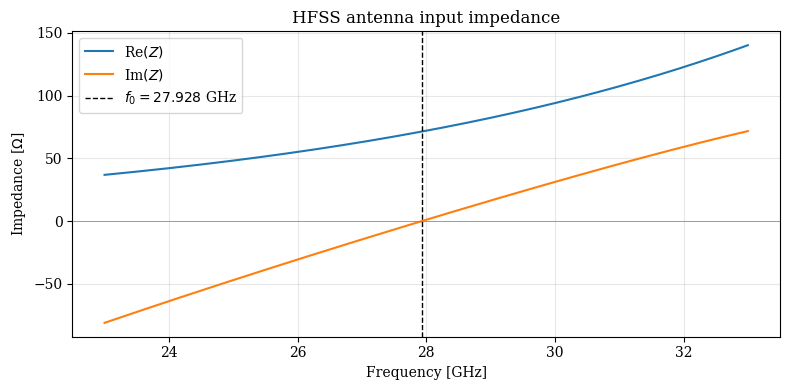

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z_data.frequency / 1e9, z_data.impedance.real, label=r"Re$(Z)$")
ax.plot(z_data.frequency / 1e9, z_data.impedance.imag, label=r"Im$(Z)$")
ax.axvline(f_resonance / 1e9, color='k', ls='--', lw=1,
           label=fr"$f_0 = {f_resonance/1e9:.3f}$ GHz")
ax.axhline(0, color='grey', lw=0.5)
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel(r"Impedance [$\Omega$]")
ax.set_title("HFSS antenna input impedance")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Construct antennas

Both antennas are placed at the same position with the same orientation.
The HFSS antenna reads its far-field pattern and impedance from the simulation CSV files; the analytical dipole derives them from closed-form expressions at the same resonant frequency.

In [5]:
hfss_ant = HFSSAntenna(
    position=ANT_POS,
    z_ax=ANT_ZAXIS,
    x_ax=ANT_XAXIS,
    efield_path=DATA["efield"],
    gain_path=DATA["gain"],
    impedance_path=DATA["impedance"],
    pattern_frequency=f_resonance,
)

dipole_ant = HalfWaveDipoleAntenna(
    position=ANT_POS,
    orientation=ANT_ZAXIS,
    resonant_frequency=f_resonance,
)

## Antenna pattern comparison

Before generating signals we compare the gain and effective-length patterns.
The antenna lies along x with its dipole axis along y, so the electron (near the origin) sits at $\theta = \pi/2$ from the antenna bore-sight — the direction of maximum gain for a dipole.

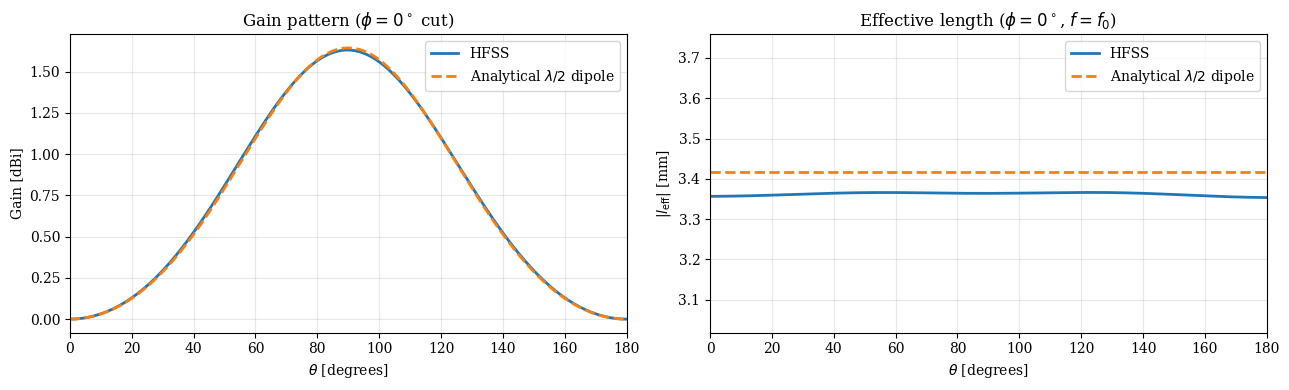

In [6]:
n_theta   = 361
theta_arr = np.linspace(0.0, np.pi, n_theta)
phi_val   = 0.0

# Unit-distance source positions in the phi=0 plane
src = np.column_stack([
    np.sin(theta_arr),
    np.zeros(n_theta),
    np.cos(theta_arr),
])

gain_hfss   = np.array([hfss_ant.get_gain(t, phi_val)   for t in theta_arr])
gain_dipole = np.array([dipole_ant.get_gain(t, phi_val) for t in theta_arr])

leff_hfss   = np.linalg.norm(
    np.abs(hfss_ant.get_effective_length(f_resonance, src)),   axis=1)
leff_dipole = np.linalg.norm(
    np.abs(dipole_ant.get_effective_length(f_resonance, src)), axis=1)

theta_deg = np.rad2deg(theta_arr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(theta_deg, gain_hfss, label=r"HFSS", lw=2)
axes[0].plot(theta_deg, gain_dipole,
             label=r"Analytical $\lambda/2$ dipole", lw=2, ls="--")
axes[0].set_xlabel(r"$\theta$ [degrees]")
axes[0].set_ylabel("Gain [dBi]")
axes[0].set_title(r"Gain pattern ($\phi = 0^\circ$ cut)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 180)

axes[1].plot(theta_deg, leff_hfss   * 1e3, label=r"HFSS", lw=2)
axes[1].plot(theta_deg, leff_dipole * 1e3,
             label=r"Analytical $\lambda/2$ dipole", lw=2, ls="--")
axes[1].set_xlabel(r"$\theta$ [degrees]")
axes[1].set_ylabel(r"$|l_{\mathrm{eff}}|$ [mm]")
axes[1].set_title(r"Effective length ($\phi = 0^\circ$, $f = f_0$)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 180)
axes[1].set_ylim(min(min(leff_dipole), min(leff_hfss)) * 0.9 * 1e3, max(max(leff_dipole), max(leff_hfss)) * 1.1 * 1e3)

plt.tight_layout()
plt.show()

## Electron trajectory and receiver chain

We generate a 10 µs trajectory of an 18.6 keV electron in the harmonic trap.
The local oscillator (LO) is placed 50 MHz below the average cyclotron frequency, so the downmixed IF signal appears near 100 MHz.

The same `traj` object is passed to both signal generators, ensuring the comparison is purely due to the antenna model and not trajectory differences.

In [7]:
particle = Particle(ke=KE, startPos=np.array([0.0, 0.0, 0.0]), 
                    pitchAngle=PITCH_ANGLE)
B0 = 2 * np.pi * f_resonance * particle.get_gamma() * particle.get_mass() / sc.e

field    = BathtubField(R_COIL, I_COIL, -TRAP_LENGTH/2, TRAP_LENGTH/2, 
                        np.array([0.0, 0.0, B0]))

f_c      = field.calc_omega_0(particle) / (2 * np.pi)
f_a      = field.calc_omega_axial(particle) / (2 * np.pi)
receiver = ReceiverChain(sample_rate=ADC_RATE, lo_frequency=f_c - LO_OFFSET)

print(f"Cyclotron frequency : {f_c / 1e9:.4f} GHz")
print(f"Axial frequency     : {f_a / 1e6:.4} MHz")
print(f"LO frequency        : {(f_c - LO_OFFSET) / 1e9:.4f} GHz")
print(f"Expected IF peak    : {LO_OFFSET / 1e6:.1f} MHz")

traj = TrajectoryGenerator(field, particle).generate(
    sample_rate=TRAJ_RATE, t_max=T_ACQ)

print(f"\nTrajectory: {traj.get_n_points()} samples, "
      f"{traj.get_duration() * 1e6:.1f} us, "
      f"{traj.get_sample_rate() / 1e9:.1f} GHz sample rate")

Cyclotron frequency : 27.9284 GHz
Axial frequency     : 0.7794 MHz
LO frequency        : 27.8284 GHz
Expected IF peak    : 100.0 MHz

Trajectory: 100001 samples, 10.0 us, 10.0 GHz sample rate


## Generate signals

`AntennaSignalGenerator` computes the Lienard-Wiechert electric field at the antenna,
projects it onto the antenna effective length, downmixes with the LO, and digitises
to the ADC sample rate.

In [8]:
gen_hfss   = AntennaSignalGenerator(traj, hfss_ant, receiver, OVERSAMPLING)
gen_dipole = AntennaSignalGenerator(traj, dipole_ant, receiver, OVERSAMPLING)

print("Generating HFSS signal...")
t_hfss,   sig_hfss   = gen_hfss.generate_signal(return_time=True)
print("Generating dipole signal...")
t_dipole, sig_dipole = gen_dipole.generate_signal(return_time=True)

print(f"\nSignal length  : {len(sig_hfss)} samples at {ADC_RATE/1e9:.0f} GHz")
print(f"HFSS RMS       : {np.sqrt(np.mean(np.abs(sig_hfss)**2)):.2e} V")
print(f"Dipole RMS     : {np.sqrt(np.mean(np.abs(sig_dipole)**2)):.2e} V")

Generating HFSS signal...
Generating dipole signal...

Signal length  : 10000 samples at 1 GHz
HFSS RMS       : 4.05e-09 V
Dipole RMS     : 4.12e-09 V


## Time-domain comparison

The real part of the complex baseband signal is plotted for the first 0.5 µs.  Both signals oscillate at the IF frequency (100 MHz) with a slowly varying amplitude from the axial bounce.

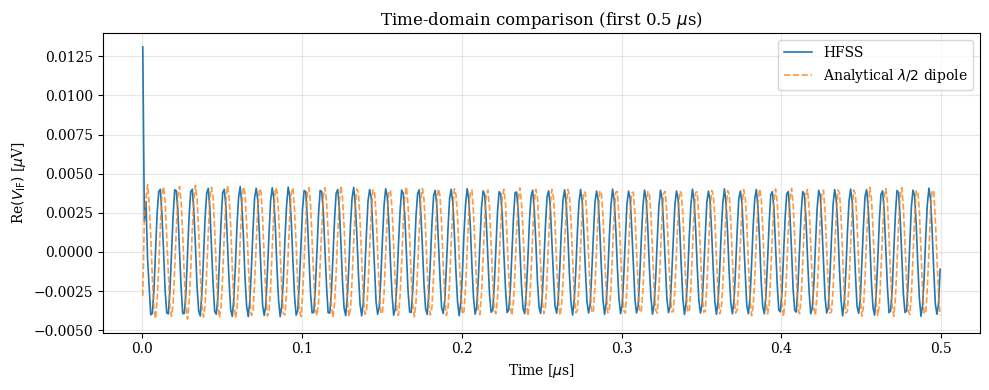

In [9]:
window_us = 0.5

mask_h = t_hfss   < window_us * 1e-6
mask_d = t_dipole < window_us * 1e-6

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_hfss[mask_h]   * 1e6, np.real(sig_hfss[mask_h])   * 1e6,
        label="HFSS", lw=1.2)
ax.plot(t_dipole[mask_d] * 1e6, np.real(sig_dipole[mask_d]) * 1e6,
        label=r"Analytical $\lambda/2$ dipole", lw=1.2, ls="--", alpha=0.8)
ax.set_xlabel(r"Time [$\mu$s]")
ax.set_ylabel(r"Re$(V_{\mathrm{IF}})$ [$\mu$V]")
ax.set_title(r"Time-domain comparison (first 0.5 $\mu$s)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Phase difference between HFSS and analytical signals

The two signals show a constant phase offset. This is **not** caused by different
antenna impedances — impedance only enters the effective length magnitude via
$\sqrt{R_\mathrm{in}}$, which is real.

The phase offset comes from the complex phase of the HFSS far-field pattern.
The analytical dipole effective length is purely real:

$$\boldsymbol{\ell}_\mathrm{eff}^\mathrm{dipole} = -\frac{\lambda}{\pi}\,F(\theta)\,\hat{\boldsymbol{\theta}}$$

while the HFSS effective length carries the phase of the normalised $rE$ pattern:

$$\boldsymbol{\ell}_\mathrm{eff}^\mathrm{HFSS} \propto \frac{rE_\theta}{|rE|}\,\hat{\boldsymbol{\theta}} + \frac{rE_\phi}{|rE|}\,\hat{\boldsymbol{\phi}}$$

where $rE_\theta$ and $rE_\phi$ are complex. This complex phase represents HFSS's
far-field phase reference and introduces a constant rotation in the baseband signal.

Below we extract this phase at the direction from the antenna toward the electron
($\theta = \pi/2$) and apply it as a correction to verify the explanation.

In [10]:
# Extract the HFSS rE phase at the direction from antenna to electron.
# The electron is near the origin; the antenna is at [0.1, 0, 0].
# In the antenna's local frame this corresponds to theta = pi/2, phi = pi
# (the -x direction from the antenna).
electron_pos = np.array([[0.0, 0.0, 0.0]])

l_eff_hfss   = hfss_ant.get_effective_length(f_resonance, electron_pos)
l_eff_dipole = dipole_ant.get_effective_length(f_resonance, electron_pos)

# The effective length vectors point along theta-hat (y-axis for this geometry).
# Extract the dominant component to get the scalar phase.
phase_hfss   = np.angle(l_eff_hfss[0, 1])    # y-component (dipole axis)
phase_dipole = np.angle(l_eff_dipole[0, 1])   # real → 0 or pi

phase_offset = phase_hfss - phase_dipole

print(f"HFSS l_eff   (y-component): {l_eff_hfss[0, 1]:.6e}")
print(f"Dipole l_eff (y-component): {l_eff_dipole[0, 1]:.6e}")
print(f"HFSS phase   : {np.rad2deg(phase_hfss):.2f} deg")
print(f"Dipole phase : {np.rad2deg(phase_dipole):.2f} deg")
print(f"Phase offset : {np.rad2deg(phase_offset):.2f} deg")

HFSS l_eff   (y-component): 2.832330e-04+3.347705e-03j
Dipole l_eff (y-component): 3.416927e-03
HFSS phase   : 85.16 deg
Dipole phase : 0.00 deg
Phase offset : 85.16 deg


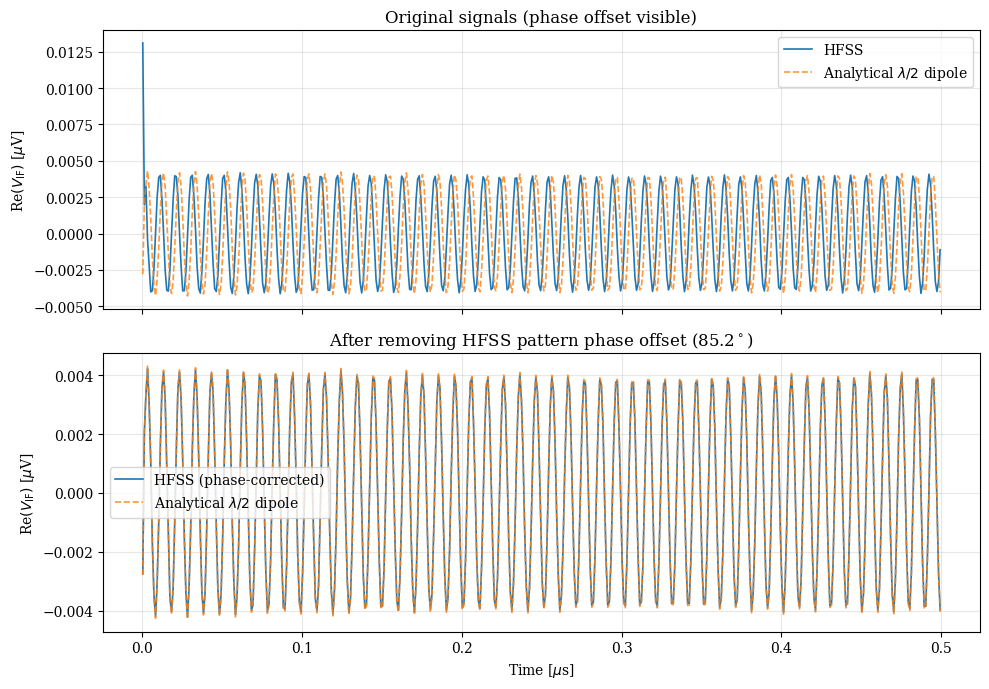

In [11]:
# Apply the phase correction to the HFSS signal and compare
sig_hfss_corrected = sig_hfss * np.exp(-1j * phase_offset)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top: original (uncorrected) signals
axes[0].plot(t_hfss[mask_h] * 1e6, np.real(sig_hfss[mask_h]) * 1e6,
             label="HFSS", lw=1.2)
axes[0].plot(t_dipole[mask_d] * 1e6, np.real(sig_dipole[mask_d]) * 1e6,
             label=r"Analytical $\lambda/2$ dipole", lw=1.2, ls="--", alpha=0.8)
axes[0].set_ylabel(r"Re$(V_{\mathrm{IF}})$ [$\mu$V]")
axes[0].set_title("Original signals (phase offset visible)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: phase-corrected HFSS signal vs analytical dipole
axes[1].plot(t_hfss[mask_h] * 1e6, np.real(sig_hfss_corrected[mask_h]) * 1e6,
             label=r"HFSS (phase-corrected)", lw=1.2)
axes[1].plot(t_dipole[mask_d] * 1e6, np.real(sig_dipole[mask_d]) * 1e6,
             label=r"Analytical $\lambda/2$ dipole", lw=1.2, ls="--", alpha=0.8)
axes[1].set_xlabel(r"Time [$\mu$s]")
axes[1].set_ylabel(r"Re$(V_{\mathrm{IF}})$ [$\mu$V]")
axes[1].set_title(
    fr"After removing HFSS pattern phase offset ({np.rad2deg(phase_offset):.1f}$^\circ$)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Frequency-domain comparison

The power spectrum (FFT) is shown for both signals.  The IF peak appears at 100 MHz for both antennas.
At 89.9° pitch angle the axial bounce produces sidebands spaced by the twice the axial frequency (because the antenna is a the centre of the trap) on either side of the mainband.

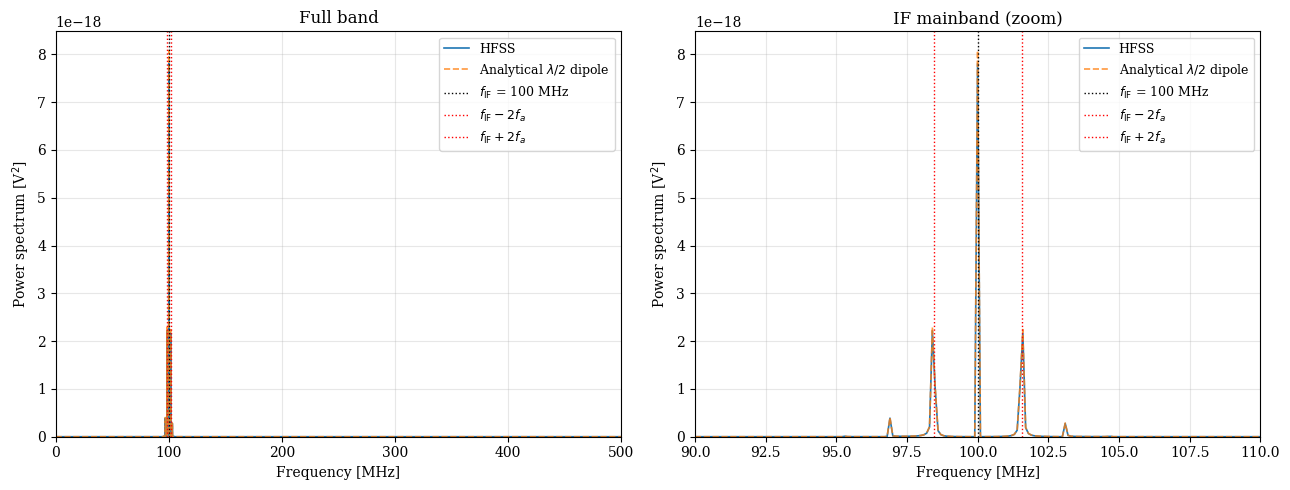

In [12]:
n    = len(sig_hfss)
freq = scipy.fft.fftshift(scipy.fft.fftfreq(n, 1 / ADC_RATE)) / 1e6  # MHz

psd_hfss   = np.abs(scipy.fft.fftshift(scipy.fft.fft(sig_hfss, norm='forward')))**2
psd_dipole = np.abs(scipy.fft.fftshift(scipy.fft.fft(sig_dipole, norm='forward')))**2

f_if = LO_OFFSET / 1e6  # MHz

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (x0, x1), title in zip(
        axes,
        [(0, 500), (f_if - 10, f_if + 10)],
        ["Full band", "IF mainband (zoom)"]):
    ax.plot(freq, psd_hfss, label="HFSS", lw=1.2)
    ax.plot(freq, psd_dipole,
            label=r"Analytical $\lambda/2$ dipole", lw=1.2, ls="--", alpha=0.8)
    ax.axvline(f_if, color='k', ls=':', lw=1,
               label=fr"$f_{{\mathrm{{IF}}}}$ = {f_if:.0f} MHz")
    ax.axvline(f_if - 2 * f_a / 1e6, color='r', ls=':', lw=1,
               label=r"$f_{\mathrm{{IF}}} - 2 f_a$")
    ax.axvline(f_if + 2 * f_a / 1e6, color='r', ls=':', lw=1,
               label=r"$f_{\mathrm{{IF}}} + 2 f_a$")
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel(r"Power spectrum [V$^2$]")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(x0, x1)
    ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

## Summary

Both antenna models produce signals that agree in:

- **Frequency**: the IF peak appears at the same frequency (100 MHz) confirming the cyclotron frequency is correctly captured by both models
- **Sideband structure**: the axial sidebands appear at the same spacing because both antennas receive from the same electron trajectory
- **Amplitude**: small differences are expected because the HFSS gain and impedance differ slightly from the analytical dipole formulae